# Project: Segmentation of endometriosis in laparoscopic images
**Etap 1: Baseline Model (U-Net)**

In [5]:
import os
import sys
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
os.chdir('..')

from src import config
from src.utils import set_seed, get_device
from src.dataset import GlendaDataset
from src.models import get_model
from src.engine import train_one_epoch, evaluate
from src.transforms import get_train_transforms, get_val_transforms

from scripts.visualize_results import run_visualization

set_seed(config.SEED)
device = get_device()
print(f"Used device: {device}")

Used device: mps


## 1. Loading data

In [6]:
train_ds = GlendaDataset(os.path.join(config.DATA_DIR, "train"), transform=get_train_transforms())
val_ds = GlendaDataset(os.path.join(config.DATA_DIR, "valid"), transform=get_val_transforms())

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f"Data: Training ({len(train_ds)}), Validation ({len(val_ds)})")

Data: Training (912), Validation (30)


## 2. Model initialization

In [7]:
model = get_model('unet').to(device)
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=1e-4)

## 3. Training

In [8]:
epochs = 2
best_val_dice = 0.0
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_dice, val_iou = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    print(f"Epoch {epoch+1}/{epochs} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f}")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), config.BASELINE_WEIGHTS)

Epoch 1/2 | Val Dice: 0.2270 | Val IoU: 0.1298


Epoch 2/2 | Val Dice: 0.3258 | Val IoU: 0.2022


## 4. Visualization

Generating overlay for test images
Generating results for: /Users/zoga/Dev/Learning/endometriosis/Glenda-1/test -> /Users/zoga/Dev/Learning/endometriosis/outputs/test_results


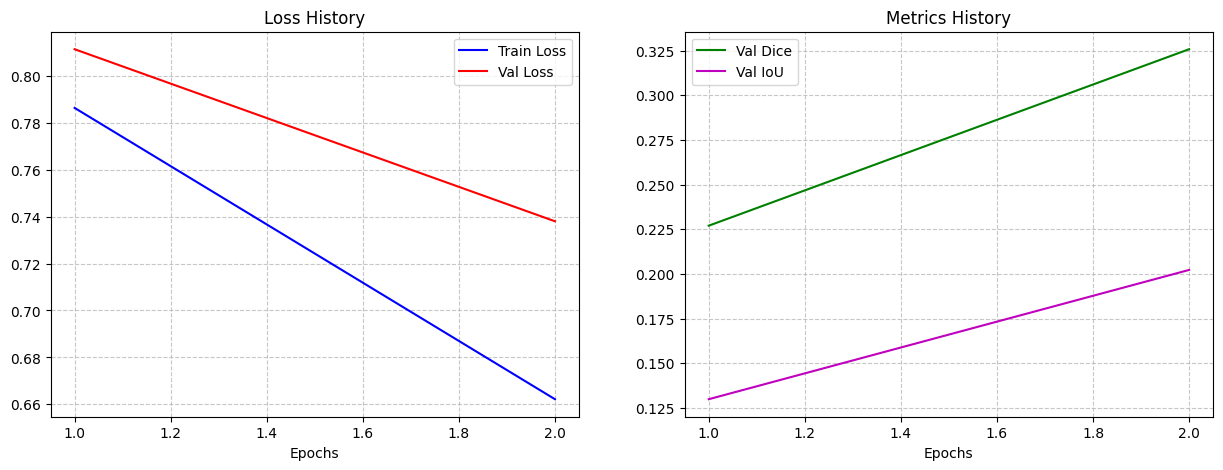

In [9]:
run_visualization(model=model, device=device, history=history)